In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

C:\Users\Harsh\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# ----------------------------
# Part A: Pandas
# ----------------------------
data = {
    "Student": ["A","B","C","D","E","F","G","H","I","J","K","L"],
    "StudyHours": [2,4,1,6,3,5,7,2,8,4,6,3],
    "PracticeHours": [1,2,0,3,2,2,4,1,4,3,3,1],
    "Attendance": [70,85,60,95,80,90,92,72,98,88,91,76],
    "SleepHours": [6,7,5,8,6,7,7,6,8,7,6,5],
    "FinalScore": [55,72,48,88,65,80,90,58,96,78,85,60]
}

In [3]:
df = pd.DataFrame(data)

print("Shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nMissing values:\n", df.isna().sum())
print("\nDescribe:\n", df.describe())

Shape: (12, 6)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Student        12 non-null     object
 1   StudyHours     12 non-null     int64 
 2   PracticeHours  12 non-null     int64 
 3   Attendance     12 non-null     int64 
 4   SleepHours     12 non-null     int64 
 5   FinalScore     12 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 708.0+ bytes
None

Missing values:
 Student          0
StudyHours       0
PracticeHours    0
Attendance       0
SleepHours       0
FinalScore       0
dtype: int64

Describe:
        StudyHours  PracticeHours  Attendance  SleepHours  FinalScore
count   12.000000      12.000000   12.000000        12.0   12.000000
mean     4.250000       2.166667   83.083333         6.5   72.916667
std      2.179449       1.267304   11.555859         1.0   15.576546
min      1.000000       0.000000   60.0

In [4]:
# Feature Engineering
df["Total_Study"] = df["StudyHours"] + df["PracticeHours"]
df["AttendanceRate"] = df["Attendance"] / 100

print("\nUpdated DataFrame:\n", df.head())


Updated DataFrame:
   Student  StudyHours  PracticeHours  Attendance  SleepHours  FinalScore  \
0       A           2              1          70           6          55   
1       B           4              2          85           7          72   
2       C           1              0          60           5          48   
3       D           6              3          95           8          88   
4       E           3              2          80           6          65   

   Total_Study  AttendanceRate  
0            3            0.70  
1            6            0.85  
2            1            0.60  
3            9            0.95  
4            5            0.80  


In [5]:
# Filter
low_att = df[df["Attendance"] < 75]
print("\nStudents with Attendance < 75:\n", low_att)


Students with Attendance < 75:
   Student  StudyHours  PracticeHours  Attendance  SleepHours  FinalScore  \
0       A           2              1          70           6          55   
2       C           1              0          60           5          48   
7       H           2              1          72           6          58   

   Total_Study  AttendanceRate  
0            3            0.70  
2            1            0.60  
7            3            0.72  


In [29]:
# Grouping
df["SleepRounded"] = df["SleepHours"].round()
print(df)

   Student  StudyHours  PracticeHours  Attendance  SleepHours  FinalScore  \
0        A           2              1          70           6          55   
1        B           4              2          85           7          72   
2        C           1              0          60           5          48   
3        D           6              3          95           8          88   
4        E           3              2          80           6          65   
5        F           5              2          90           7          80   
6        G           7              4          92           7          90   
7        H           2              1          72           6          58   
8        I           8              4          98           8          96   
9        J           4              3          88           7          78   
10       K           6              3          91           6          85   
11       L           3              1          76           5          60   

In [33]:
grouped = df.groupby("SleepRounded")["FinalScore"].mean()
print("\nMean FinalScore by rounded SleepHours:\n", grouped)
print("\nUpdated DataFrame:\n", df.head())


Mean FinalScore by rounded SleepHours:
 SleepRounded
5    54.00
6    65.75
7    80.00
8    92.00
Name: FinalScore, dtype: float64

Updated DataFrame:
   Student  StudyHours  PracticeHours  Attendance  SleepHours  FinalScore  \
0       A           2              1          70           6          55   
1       B           4              2          85           7          72   
2       C           1              0          60           5          48   
3       D           6              3          95           8          88   
4       E           3              2          80           6          65   

   Total_Study  AttendanceRate  SleepRounded AttendanceCategory  
0            3            0.70             6                Low  
1            6            0.85             7             Medium  
2            1            0.60             5                Low  
3            9            0.95             8               High  
4            5            0.80             6             Medi

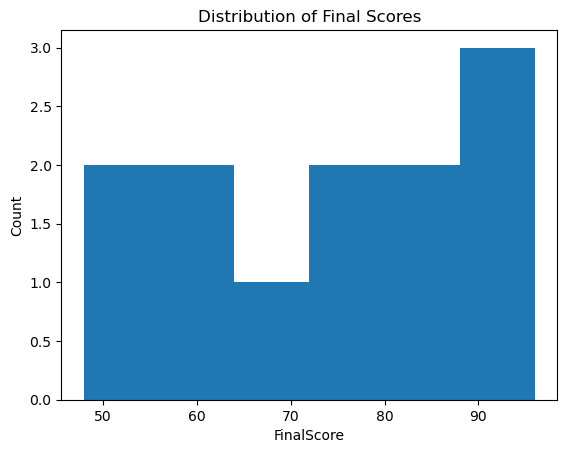

In [7]:
# Part B: Matplotlib
# ----------------------------
# 1) Histogram
plt.figure()
plt.hist(df["FinalScore"], bins=6)
plt.title("Distribution of Final Scores")
plt.xlabel("FinalScore")
plt.ylabel("Count")
plt.show()

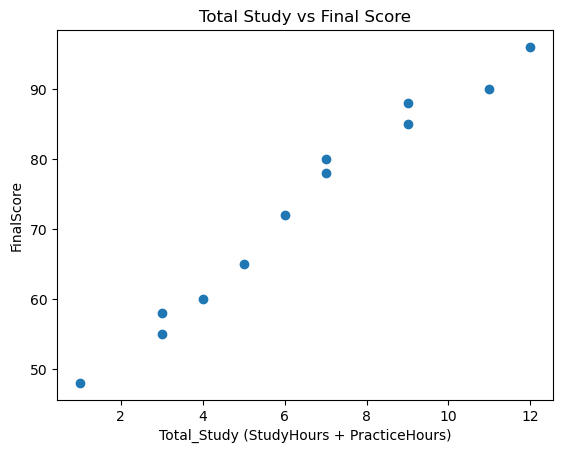

In [8]:
# 2) Scatter: Total_Study vs FinalScore
plt.figure()
plt.scatter(df["Total_Study"], df["FinalScore"])
plt.title("Total Study vs Final Score")
plt.xlabel("Total_Study (StudyHours + PracticeHours)")
plt.ylabel("FinalScore")
plt.show()

In [11]:
# 3) Bar: Avg score by attendance category
def att_category(a):
    if a < 75:
        return "Low"
    elif a <= 90:
        return "Medium"
    return "High"

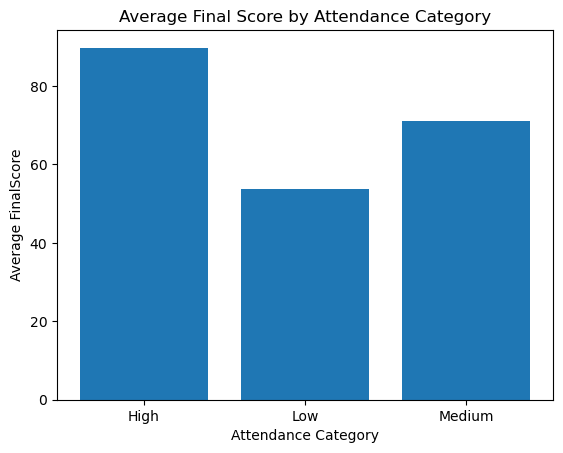

In [12]:
df["AttendanceCategory"] = df["Attendance"].apply(att_category)
avg_by_cat = df.groupby("AttendanceCategory")["FinalScore"].mean()

plt.figure()
plt.bar(avg_by_cat.index, avg_by_cat.values)
plt.title("Average Final Score by Attendance Category")
plt.xlabel("Attendance Category")
plt.ylabel("Average FinalScore")
plt.show()


In [13]:
# ----------------------------
# Part C: Scikit-learn
# ----------------------------
X = df[["StudyHours", "PracticeHours", "Attendance", "SleepHours"]]
y = df["FinalScore"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nEvaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 :", r2_score(y_test, y_pred))


Evaluation:
MAE: 3.2920830275315587
MSE: 11.092187817379047
R2 : 0.932456231152631


In [28]:
# Prediction for new student
new_student = pd.DataFrame([{
    "StudyHours": 5,
    "PracticeHours":0,
    "Attendance": 98,
    "SleepHours": 8
}])

pred_score = model.predict(new_student)[0]
print("\nPredicted Final Score for new student:", round(pred_score, 2))


Predicted Final Score for new student: 82.0
